In [1]:
import time, joblib, glob, re
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [2]:
run_num = 93
dfs = []
for i in range(10):
    d = pd.read_pickle(f"./Syn{run_num}_mrt_{i+1}.pickle")
    dfs.append(pd.DataFrame(d) if isinstance(d, list) else d)
df = pd.concat(dfs, ignore_index=True)

In [3]:
df

,pl_orbper,pl_orbsmax,pl_radj,pl_massj,pl_eqt,Coeff,b1,st_teff,st_rad,st_mass,...,i_bw,i,i_bw_err_low,i_bw_err_up,i_err,z_bw,z,z_bw_err_low,z_bw_err_up,z_err
0,1,0.019572,0.982913,9.028319,1333.208737,1.100311,0.320080,5500,1,1,...,7486.022892,0.010276,583.726235,685.432784,0.000093,8955.060521,0.010273,684.172662,494.268237,0.000085
1,1,0.019572,0.906402,1.961081,629.110864,1.241706,0.326048,5500,1,1,...,7486.022892,0.008803,583.726235,685.432784,0.000080,8955.060521,0.008788,684.172662,494.268237,0.000073
2,1,0.019572,0.916328,27.009671,608.376919,1.066579,0.353166,5500,1,1,...,7486.022892,0.008873,583.726235,685.432784,0.000080,8955.060521,0.008872,684.172662,494.268237,0.000074
3,1,0.019572,0.943680,9.227830,560.106668,1.183514,0.345988,5500,1,1,...,7486.022892,0.009420,583.726235,685.432784,0.000085,8955.060521,0.009419,684.172662,494.268237,0.000078
4,1,0.019572,0.885380,13.788546,928.160370,0.973283,0.339702,5500,1,1,...,7486.022892,0.008289,583.726235,685.432784,0.000075,8955.060521,0.008288,684.172662,494.268237,0.000069
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,0.019572,0.971792,31.233374,868.007501,1.071154,0.342669,5500,1,1,...,7486.022892,0.009990,583.726235,685.432784,0.000091,8955.060521,0.009988,684.172662,494.268237,0.000083
99996,1,0.019572,0.862298,17.156403,683.355272,1.116959,0.330496,5500,1,1,...,7486.022892,0.007861,583.726235,685.432784,0.000071,8955.060521,0.007860,684.172662,494.268237,0.000065
99997,1,0.019572,0.988605,3.616451,619.230955,1.003496,0.373489,5500,1,1,...,7486.022892,0.010433,583.726235,685.432784,0.000095,8955.060521,0.010420,684.172662,494.268237,0.000087
99998,1,0.019572,0.921262,17.485540,750.140583,1.133354,0.333631,5500,1,1,...,7486.022892,0.008973,583.726235,685.432784,0.000081,8955.060521,0.008972,684.172662,494.268237,0.000074


In [4]:
target_names = ['pl_eqt', 'MR_TiO', 'MR_VO']
bands = ['U','B','V','R','I','u','g','r','i','z']

y = np.log10(df[target_names].values)
X_raw = df[bands].div(df['pl_radj']**2, axis=0)
X = StandardScaler().fit_transform(X_raw)
col_names = list(X_raw.columns)

In [7]:
seed = 42
train_ratio = 0.70
validation_ratio = 0.20
test_ratio = 0.10

X_train, X_temp, y_train, y_temp = train_test_split(X_raw, y,
                                                    test_size = 1 - train_ratio, 
                                                    shuffle = True,
                                                    random_state = seed)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp,
                                                test_size = test_ratio / (test_ratio + validation_ratio),
                                                shuffle = True,
                                                random_state  = seed)

data = {'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test}
joblib.dump(data, f'./Syn{run_num}_split_raw_data.pkl')

['./Syn93_split_raw_data.pkl']

In [6]:
data = joblib.load(f'./Syn{run_num}_split_data.pkl')
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']

In [7]:
param_grid = {'n_estimators': np.logspace(1,3,10,dtype=int), 'max_depth':   np.logspace(1,2,10,dtype=int)}

In [8]:
def save_preds(model, X, y_true, names, prefix, step):
    y_pred = model.predict(X)
    df = pd.DataFrame({f'y_true_{n}':  y_true[:, i] for i, n in enumerate(names)}|{f'y_pred_{n}':  y_pred[:,  i] for i, n in enumerate(names)})
    df.to_csv(f"{prefix}_step{step}_run{run_num}.csv", index=False)

In [ ]:
remaining_bands = bands.copy()
history, step_times = [], []
step = 0

while len(remaining_bands) >= 2:
    step += 1
    feats = remaining_bands
    idxs  = [col_names.index(f) for f in feats]

    grid = GridSearchCV(
        RandomForestRegressor(random_state=101),
        param_grid, scoring="r2",
        cv=5, n_jobs=15, verbose=1,
        return_train_score=True
    )
    t0 = time.time()
    grid.fit(X_train[:, idxs], y_train)
    step_times.append(time.time() - t0)

    fn_cv   = f"gridsearch_results_no_err_step{step}_run{run_num}.csv"
    fn_model= f"rf_no_err_step{step}_run{run_num}.pkl"
    fn_imp  = f"importances_no_err_step{step}_run{run_num}.csv"

    pd.DataFrame(grid.cv_results_).to_csv(fn_cv, index=False)
    joblib.dump(grid.best_estimator_, fn_model, compress=1)
    (
      pd.Series(grid.best_estimator_.feature_importances_, index=feats)
        .to_frame("importance")
        .to_csv(fn_imp)
    )

    save_preds(grid.best_estimator_, X_train[:, idxs], y_train, target_names, 'pred_train', step)
    save_preds(grid.best_estimator_, X_val[:,   idxs], y_val,   target_names, 'pred_val',   step)
    save_preds(grid.best_estimator_, X_test[:,  idxs], y_test,  target_names, 'pred_test',  step)

    history.append(pd.Series(grid.best_estimator_.feature_importances_, index=feats))

    if len(remaining_bands) == 2:
        break

    worst = history[-1].idxmin()
    remaining_bands.remove(worst)

imp_df = pd.DataFrame(history).T
imp_df.columns = [f"Step{i+1}" for i in range(imp_df.shape[1])]
imp_df.to_csv(f"importance_evolution_no_err_run{run_num}.csv", index=True)

pd.DataFrame({
    "step":         list(range(1, step+1)),
    "duration_sec": step_times,
    "duration_min": [d/60 for d in step_times]
}).to_csv(f"step_times_no_err_run{run_num}.csv", index=False)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


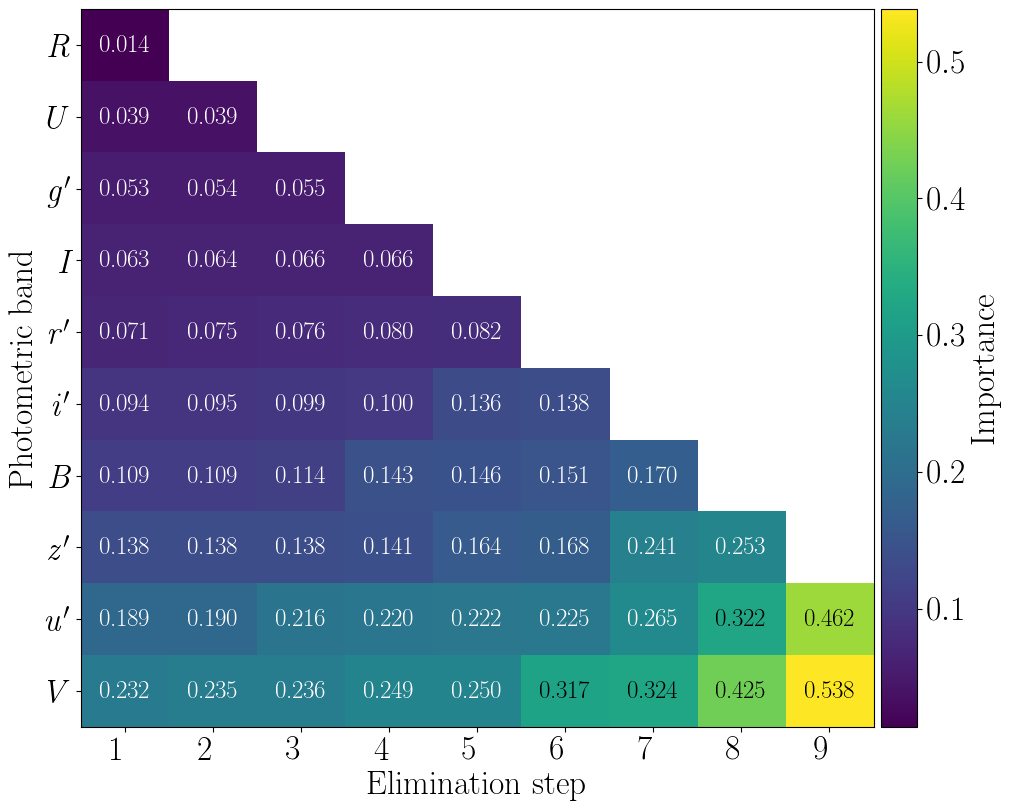

In [11]:
mpl.rcParams.update({
    'font.family'      : 'serif',
    'font.serif'       : ['Times New Roman'],
    'text.usetex'      : True,
    'font.size'        : 24,
    'font.weight'      : 'bold', 
    'axes.labelweight' : 'bold',
})

imp_df = pd.read_csv(f"importance_evolution_no_err_run{run_num}.csv", index_col=0)

elim_step = {}
for b in imp_df.index:
    nan_mask = imp_df.loc[b].isna()
    elim_step[b] = (int(nan_mask.idxmax().replace("Step", "")) if nan_mask.any() else len(imp_df.columns) + 1)

last = imp_df.columns[-1]
last_depth = imp_df.loc[:, last].fillna(np.inf)
sorted_bands = sorted(imp_df.index, key=lambda b: (elim_step[b], last_depth[b]))

imp_df = imp_df.loc[sorted_bands]

data = imp_df.values.astype(float)
mask = np.zeros_like(data, dtype=bool)
for i, band in enumerate(sorted_bands):
    drop_at = elim_step[band]
    mask[i, drop_at - 1:] = True

data_masked = np.ma.masked_array(data, mask=mask)

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
im = ax.imshow(data_masked, aspect='auto', cmap='viridis')

def stylize_label(band):
    if band.islower():
        return rf"$\it{{{band}}}^\prime$"
    else:
        return rf"$\it{{{band}}}$"

y_labels = [stylize_label(b) for b in sorted_bands]


ax.set_xticks(np.arange(len(imp_df.columns)))
ax.set_xticklabels(np.arange(1, len(imp_df.columns) + 1), rotation=0, ha='right', fontsize=24)
ax.set_yticks(np.arange(len(sorted_bands)))
ax.set_yticklabels(y_labels, fontsize=24)
ax.set_xlabel("Elimination step", fontsize=24)
ax.set_ylabel("Photometric band", fontsize=24)

vmin, vmax = np.nanmin(data), np.nanmax(data)
mid = vmin + 0.5 * (vmax - vmin)

for i in range(len(sorted_bands)):
    for j in range(len(imp_df.columns)):
        if not mask[i, j]:
            val = data[i, j]
            txt_color = "black" if val > mid else "white"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", color=txt_color, fontsize=18)

cbar = fig.colorbar(im, ax=ax, pad = 0.01)
cbar.ax.tick_params(labelsize=24)
cbar.set_label("Importance", fontsize=24)

#plt.tight_layout()
plt.savefig(f"Rank_importance_no_err_{run_num}.pdf", dpi=500)
plt.show()